<a href="https://colab.research.google.com/github/440g/painkiller/blob/FirstEvaluation/FirstEvaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluation; model Interpretation & Analysis
* Interpret the trained models and analyze predictive performance.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
cd /content/drive/MyDrive/painkiller/models

/content/drive/MyDrive/painkiller/models


In [ ]:
from joblib import load
model = load('GradientBoosting_final.joblib')

In [ ]:
X_train = pd.read_csv('../datasets/X_train.csv').drop(columns=['Unnamed: 0'])
y_train = pd.read_csv('../datasets/y_train.csv')
X_valid = pd.read_csv('../datasets/X_val.csv').drop(columns=['Unnamed: 0'])
y_valid = pd.read_csv('../datasets/y_val.csv')
X_test = pd.read_csv('../datasets/X_test.csv').drop(columns=['Unnamed: 0', 'id'])
y_pred = pd.read_csv('../datasets/prediction.csv').drop(columns=['id', 'probability'])

##Feature Importance

###Gini Importance

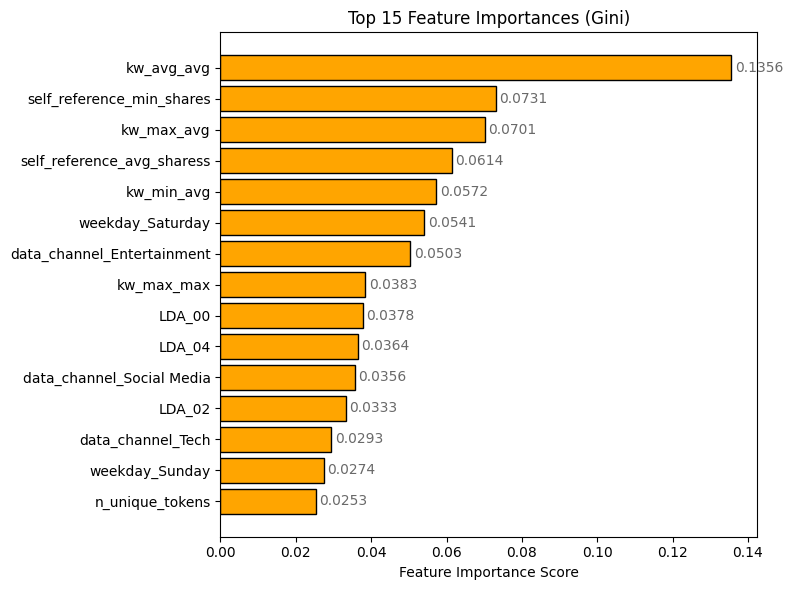

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from joblib import load
from sklearn.inspection import permutation_importance
import os

# Gini 중요도 시각화
importances = model.feature_importances_
sorted_idx = importances.argsort()[-15:]

plt.figure(figsize=(8, 6))
plt.barh(
    np.arange(len(sorted_idx)),
    importances[sorted_idx],
    color='orange',
    edgecolor='black'
)
plt.yticks(np.arange(len(sorted_idx)), labels=X_train.columns[sorted_idx])
plt.xlabel('Feature Importance Score')
plt.title('Top 15 Feature Importances (Gini)')
for i, v in enumerate(importances[sorted_idx]):
    plt.text(v + 0.001, i, f"{v:.4f}", color='dimgray', va='center')
plt.tight_layout()
plt.show()

###Permutation Importance

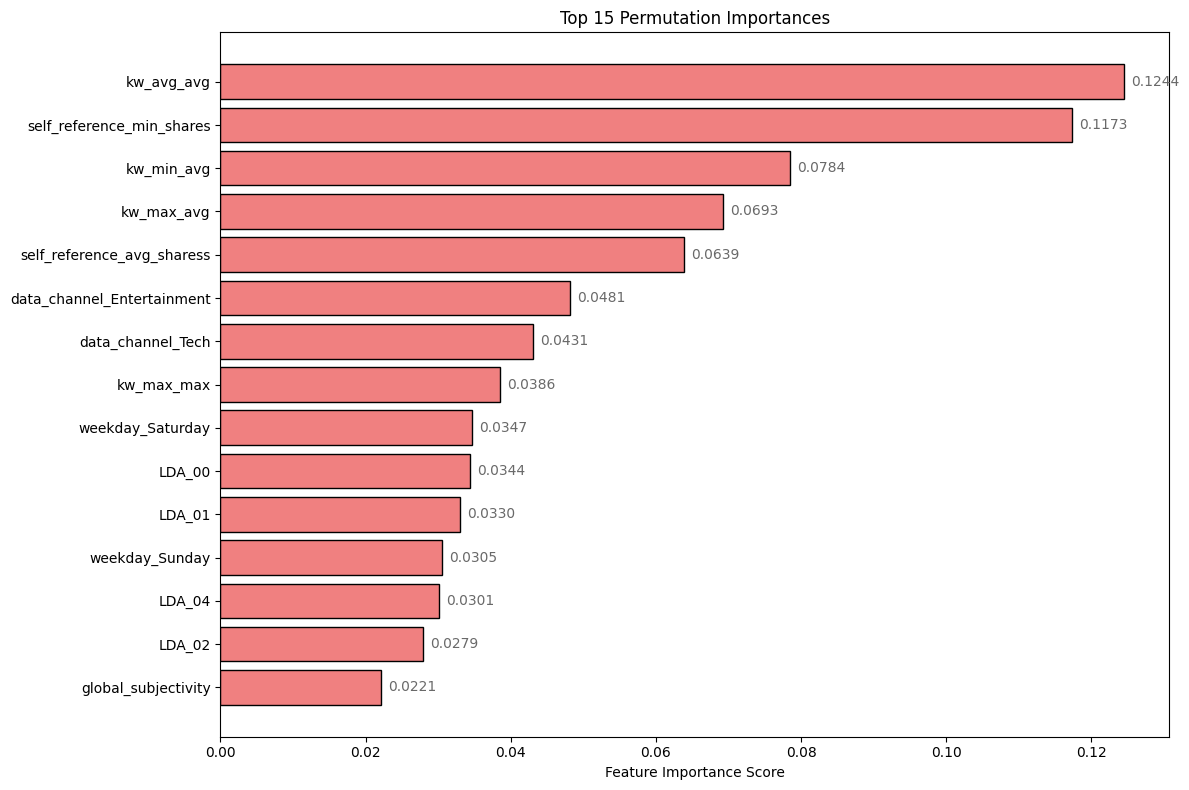

In [ ]:
# 순열 중요도 계산
perm_importance = permutation_importance(
    model,
    X_test,
    y_pred,
    n_repeats=10,
    random_state=42
)

# 순열 중요도 시각화
sorted_perm_idx = perm_importance.importances_mean.argsort()[-15:]

plt.figure(figsize=(12, 8))
plt.barh(
    X_test.columns[sorted_perm_idx],
    perm_importance.importances_mean[sorted_perm_idx],
    color='lightcoral',
    edgecolor='black'
)
plt.xlabel('Feature Importance Score')
plt.title('Top 15 Permutation Importances')
for i, v in enumerate(perm_importance.importances_mean[sorted_perm_idx]):
    plt.text(v + 0.001, i, f"{v:.4f}", color='dimgray', va='center')
plt.tight_layout()
plt.show()

###SHAP

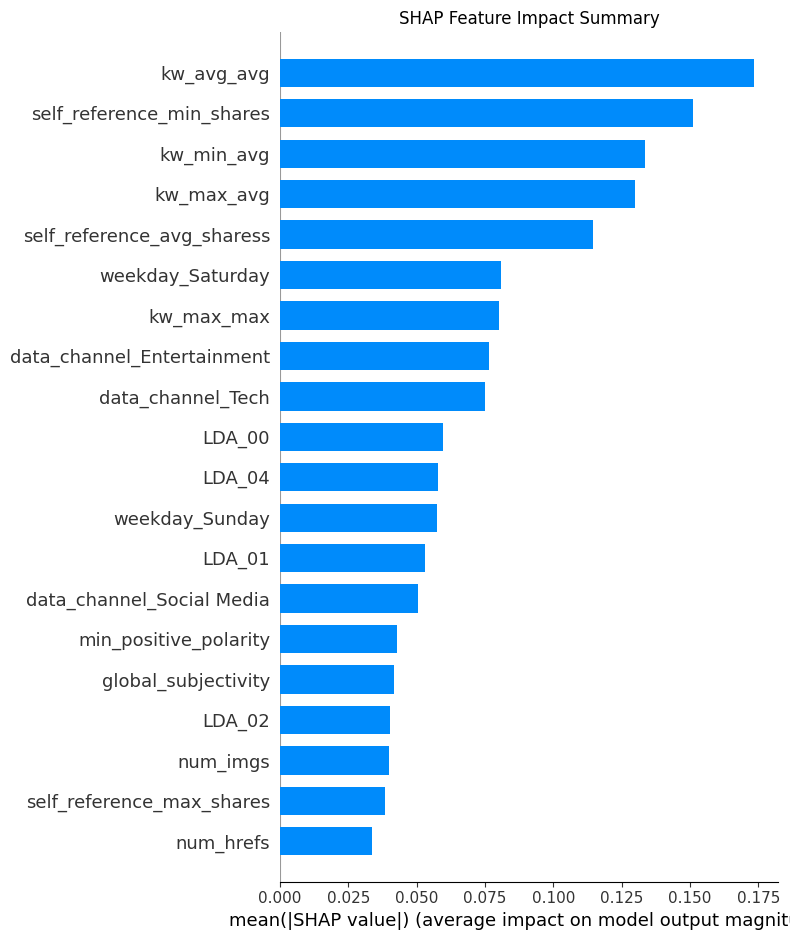

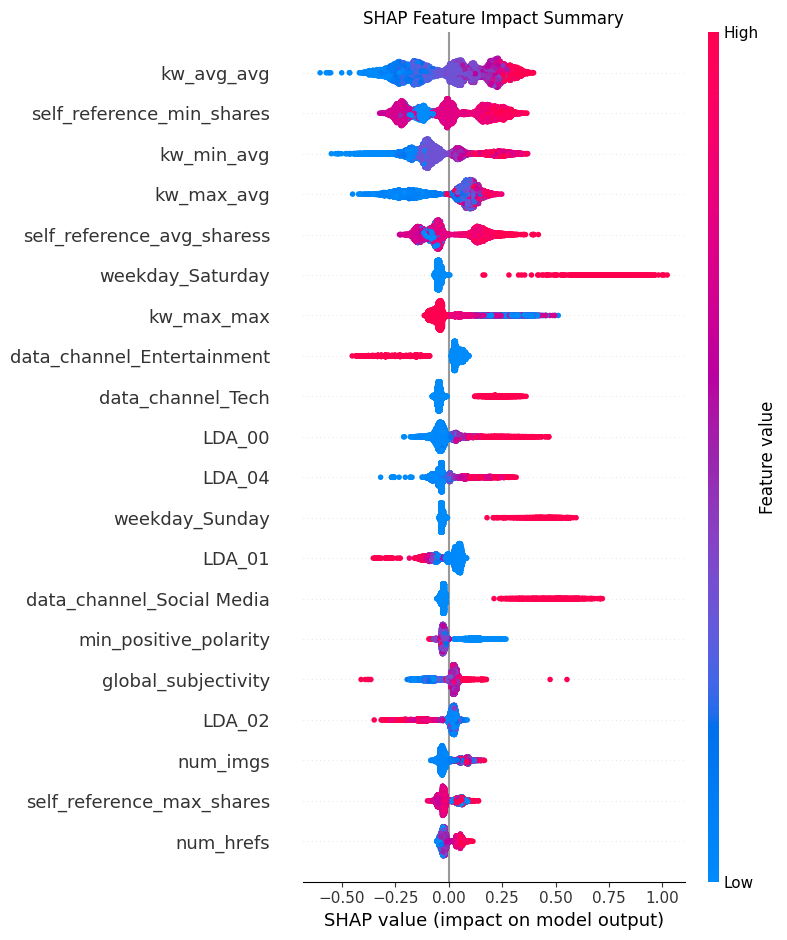

<Figure size 640x480 with 0 Axes>

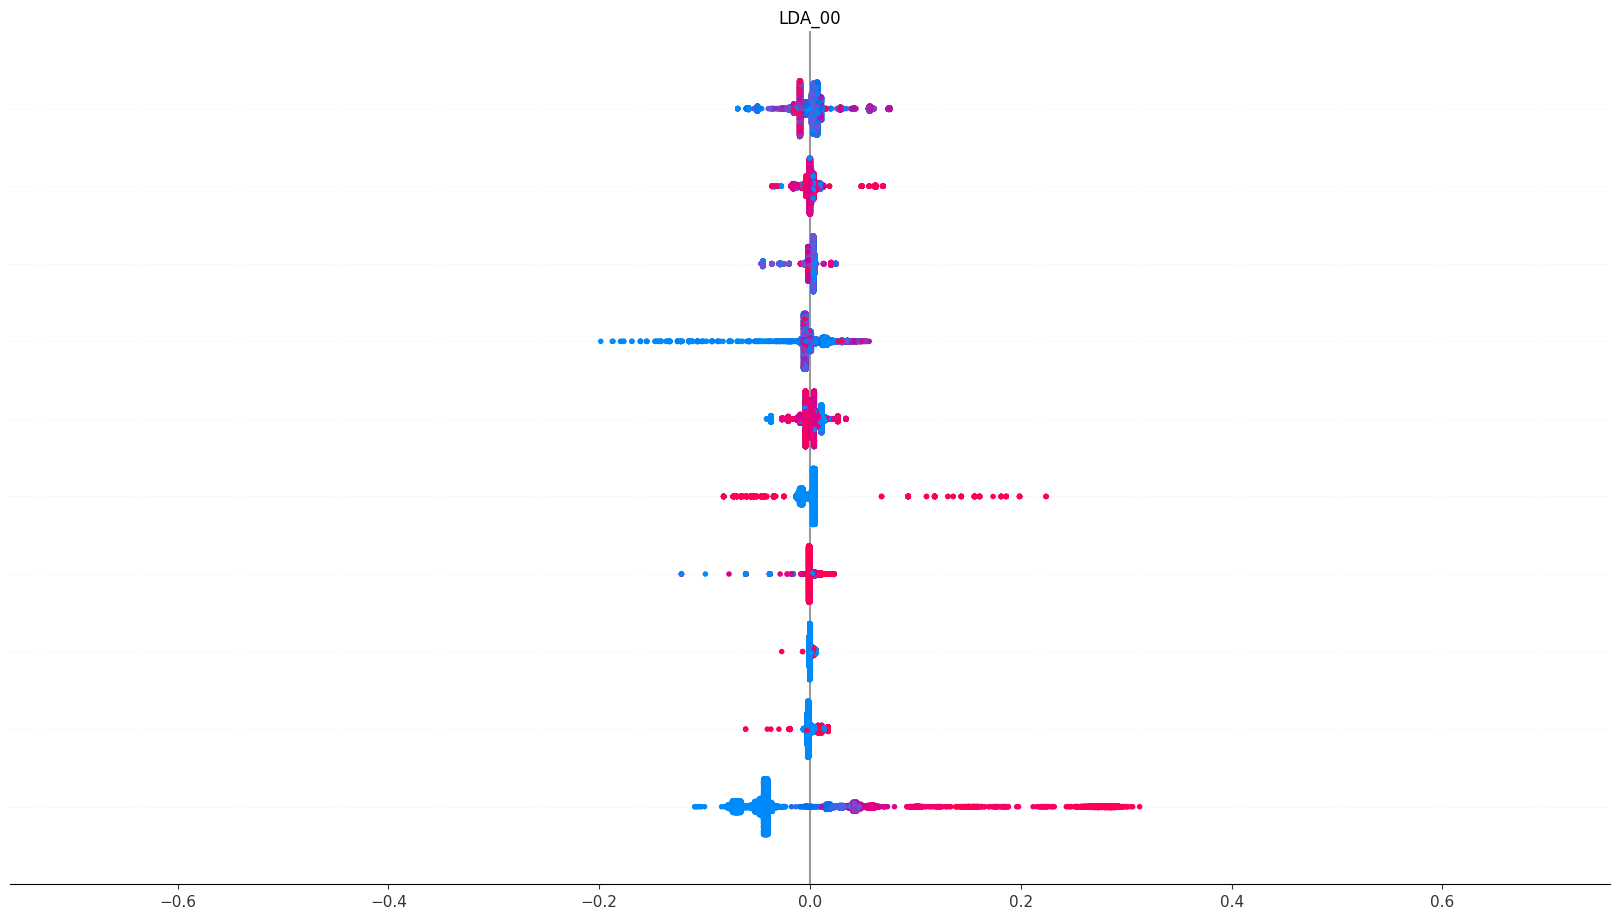

In [ ]:
!pip install shap

import shap

# SHAP Explainer 초기화
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# 전체 특징 영향력 요약
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('SHAP Feature Impact Summary')
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values, X_test, plot_type="dot", show=False)
plt.title('SHAP Feature Impact Summary')
plt.tight_layout()
plt.show()


# 상호작용 효과 분석
shap_interaction = explainer.shap_interaction_values(X_test)
shap.summary_plot(shap_interaction, X_test, max_display=10)
